# 🔗 Pipeline Complete Guide
## End-to-End ML Workflows in One Object

---

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print("🔗 Ready to build Pipelines!")

✅ Libraries imported successfully!
🔗 Ready to build Pipelines!


## 2. 📊 Create COVID Dataset

In [3]:
np.random.seed(42)
n_samples = 1000

# Generate synthetic data similar to your COVID dataset
data = {
    'age': np.random.randint(18, 80, n_samples),
    'fever': np.random.normal(98.6, 2, n_samples),
    'gender': np.random.choice(['Male', 'Female'], n_samples),
    'city': np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Chennai'], n_samples),
    'cough': np.random.choice(['Mild', 'Strong'], n_samples)
}

df = pd.DataFrame(data)

# Add some missing values to fever (like your dataset)
missing_indices = np.random.choice(df.index, size=50, replace=False)
df.loc[missing_indices, 'fever'] = np.nan

# Create realistic target
df['has_covid'] = (
    (df['fever'].fillna(98.6) > 100) &
    (df['cough'] == 'Strong') &
    (df['age'] > 40)
).astype(int)

print(f"📊 COVID Dataset created: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nData types:")
print(df.dtypes)

print(f"\nCOVID distribution:")
print(df['has_covid'].value_counts())

📊 COVID Dataset created: (1000, 6)

First 5 rows:
   age       fever  gender    city   cough  has_covid
0   56  101.344756  Female   Delhi    Mild          0
1   69   97.244428  Female  Mumbai    Mild          0
2   46  100.907064  Female   Delhi  Strong          1
3   32   97.849979  Female  Mumbai    Mild          0
4   60   97.211708  Female  Mumbai    Mild          0

Missing values:
age           0
fever        50
gender        0
city          0
cough         0
has_covid     0
dtype: int64

Data types:
age            int32
fever        float64
gender        object
city          object
cough         object
has_covid      int64
dtype: object

COVID distribution:
has_covid
0    913
1     87
Name: count, dtype: int64


In [4]:
# 3. 🔧 Building Your First Pipeline

# Step 1: Identify feature types (same as your analysis)
numerical_features = ['age', 'fever']
ordinal_features = ['cough']
nominal_features = ['gender', 'city']

print("🔍 Feature Classification:")
print(f"📊 Numerical: {numerical_features}")
print(f"📊 Ordinal: {ordinal_features}")
print(f"🏷️  Nominal: {nominal_features}")

# Step 2: Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        # Handle numerical features (impute missing fever + scale)
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numerical_features),

        # Handle ordinal features (like your cough: Mild < Strong)
        ('ord', OrdinalEncoder(categories=[
         ['Mild', 'Strong']]), ordinal_features),

        # Handle nominal features (like your gender, city)
        ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_features)
    ]
)

print("✅ Preprocessor created!")
print("   📊 Numerical → Impute + Scale")
print("   📊 Ordinal → Encode order")
print("   🏷️  Nominal → One-hot encode")

# Step 3: Create complete pipeline
covid_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

print("\n🔗 Complete Pipeline created!")
print("Pipeline steps:")
for i, (name, step) in enumerate(covid_pipeline.steps, 1):
    print(f"  {i}. {name}: {type(step).__name__}")

🔍 Feature Classification:
📊 Numerical: ['age', 'fever']
📊 Ordinal: ['cough']
🏷️  Nominal: ['gender', 'city']
✅ Preprocessor created!
   📊 Numerical → Impute + Scale
   📊 Ordinal → Encode order
   🏷️  Nominal → One-hot encode

🔗 Complete Pipeline created!
Pipeline steps:
  1. preprocessor: ColumnTransformer
  2. classifier: LogisticRegression


In [5]:
# 4. 🚀 Training and Testing

# Split data (like your example)
X = df.drop('has_covid', axis=1)
y = df['has_covid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Data split:")
print(f"   Training: {X_train.shape}")
print(f"   Test: {X_test.shape}")

# Train pipeline (ONE STEP!)
print("\n🚀 Training pipeline...")
covid_pipeline.fit(X_train, y_train)

# Make predictions (ONE STEP!)
print("🔮 Making predictions...")
y_pred = covid_pipeline.predict(X_test)
y_pred_proba = covid_pipeline.predict_proba(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 Results:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Correct: {sum(y_pred == y_test)}/{len(y_test)}")

print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No COVID', 'COVID']))

📊 Data split:
   Training: (800, 5)
   Test: (200, 5)

🚀 Training pipeline...
🔮 Making predictions...

📊 Results:
   Accuracy: 0.9500
   Correct: 190/200

📋 Detailed Classification Report:
              precision    recall  f1-score   support

    No COVID       0.97      0.98      0.97       183
       COVID       0.73      0.65      0.69        17

    accuracy                           0.95       200
   macro avg       0.85      0.81      0.83       200
weighted avg       0.95      0.95      0.95       200



In [6]:
# 5. 🆚 Compare: Your Method vs Pipeline

# Recreate your manual method for comparison
def manual_method(X_train, X_test, y_train, y_test):
    """Your original manual preprocessing method"""

    print("🔧 Manual Method (Your Original Code):")

    # Step 1: Handle fever (numerical)
    si = SimpleImputer()
    X_train_fever = si.fit_transform(X_train[['fever']])
    X_test_fever = si.transform(X_test[['fever']])

    # Step 2: Handle cough (ordinal)
    oe = OrdinalEncoder(categories=[['Mild', 'Strong']])
    X_train_cough = oe.fit_transform(X_train[['cough']])
    X_test_cough = oe.transform(X_test[['cough']])

    # Step 3: Handle gender, city (nominal)
    ohe = OneHotEncoder(drop='first')
    X_train_gender_city = ohe.fit_transform(
        X_train[['gender', 'city']]).toarray()
    X_test_gender_city = ohe.transform(X_test[['gender', 'city']]).toarray()

    # Step 4: Handle age (keep as is)
    X_train_age = X_train[['age']].values
    X_test_age = X_test[['age']].values

    # Step 5: Concatenate everything manually
    X_train_transformed = np.concatenate([
        X_train_age, X_train_fever, X_train_gender_city, X_train_cough
    ], axis=1)
    X_test_transformed = np.concatenate([
        X_test_age, X_test_fever, X_test_gender_city, X_test_cough
    ], axis=1)

    # Step 6: Train model
    model = LogisticRegression(random_state=42)
    model.fit(X_train_transformed, y_train)

    # Step 7: Predict
    y_pred_manual = model.predict(X_test_transformed)
    accuracy_manual = accuracy_score(y_test, y_pred_manual)

    print(f"   Manual Method Accuracy: {accuracy_manual:.4f}")
    return accuracy_manual


# Test both methods
manual_accuracy = manual_method(X_train, X_test, y_train, y_test)
pipeline_accuracy = accuracy

print(f"\n🆚 COMPARISON:")
print(f"   Manual Method: {manual_accuracy:.4f}")
print(f"   Pipeline Method: {pipeline_accuracy:.4f}")
print(f"   Difference: {abs(pipeline_accuracy - manual_accuracy):.4f}")

if abs(pipeline_accuracy - manual_accuracy) < 0.001:
    print("✅ Same results! But Pipeline is much cleaner!")
else:
    print("⚠️ Different results - check preprocessing steps")

🔧 Manual Method (Your Original Code):
   Manual Method Accuracy: 0.9500

🆚 COMPARISON:
   Manual Method: 0.9500
   Pipeline Method: 0.9500
   Difference: 0.0000
✅ Same results! But Pipeline is much cleaner!


In [7]:
# 🎯 Grid Search with Pipeline

# Search for best parameters across the entire pipeline
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'classifier__C': [0.1, 1, 10],
    'classifier__max_iter': [100, 1000]
}

grid_search = GridSearchCV(
    covid_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

print("\n🔍 GRID SEARCH OPTIMIZATION")
print("=" * 40)
print("🚀 Searching for best parameters...")

grid_search.fit(X_train, y_train)

print(f"✅ Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best CV Score: {grid_search.best_score_:.4f}")

# Test best pipeline
best_pipeline = grid_search.best_estimator_
y_pred_best = best_pipeline.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)

print(f"📈 Test Accuracy (Optimized): {best_accuracy:.4f}")


🔍 GRID SEARCH OPTIMIZATION
🚀 Searching for best parameters...
✅ Best parameters found:
   classifier__C: 10
   classifier__max_iter: 100
   preprocessor__num__imputer__strategy: mean

📊 Best CV Score: 0.9512
📈 Test Accuracy (Optimized): 0.9600


🏆 PIPELINE COMPARISON

Logistic Regression:
   CV Score: 0.9513 ± 0.0121
   Test Accuracy: 0.9500

Random Forest:
   CV Score: 0.9950 ± 0.0047
   Test Accuracy: 1.0000
🔧 Manual Method (Your Original Code):
   Manual Method Accuracy: 0.9500


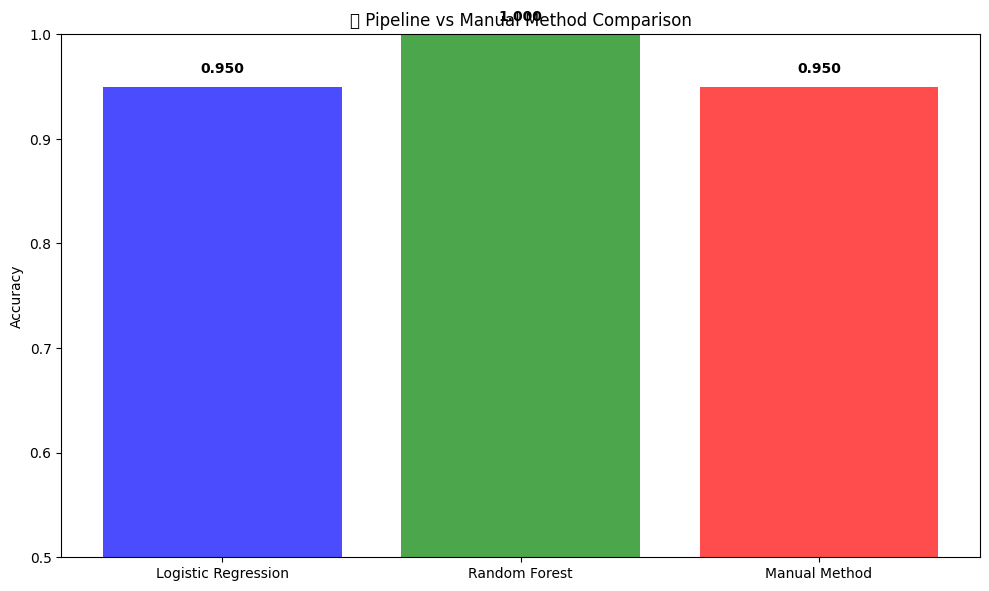


🎯 Best performing method: Random Forest


In [8]:
# 7. 🔗 Multiple Pipeline Comparison

# Compare different algorithms in pipelines
pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),

    'Manual Method': 'manual'  # Your original approach
}

print("🏆 PIPELINE COMPARISON")
print("=" * 50)

results = {}

for name, pipeline in pipelines.items():
    if name == 'Manual Method':
        # Use your manual method
        accuracy = manual_method(X_train, X_test, y_train, y_test)
        results[name] = accuracy
    else:
        # Use pipeline
        cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
        pipeline.fit(X_train, y_train)
        test_accuracy = accuracy_score(y_test, pipeline.predict(X_test))
        results[name] = test_accuracy

        print(f"\n{name}:")
        print(f"   CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        print(f"   Test Accuracy: {test_accuracy:.4f}")

# Visualize comparison
plt.figure(figsize=(10, 6))
names = list(results.keys())
scores = list(results.values())
colors = ['blue', 'green', 'red']

bars = plt.bar(names, scores, color=colors, alpha=0.7)
plt.title('🏆 Pipeline vs Manual Method Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)

# Add value labels
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🎯 Best performing method: {max(results, key=results.get)}")

In [9]:
# 🔗 PROFESSIONAL TEMPLATE - COPY FOR YOUR PROJECTS!

def create_ml_pipeline(numerical_cols, ordinal_cols, nominal_cols,
                       ordinal_categories=None, model=None):
    """
    Create complete ML pipeline for mixed data types
    
    Parameters:
    numerical_cols: list of numerical column names
    ordinal_cols: list of ordinal column names  
    nominal_cols: list of nominal column names
    ordinal_categories: list of lists, categories for each ordinal column
    model: sklearn model (default: LogisticRegression)
    
    Returns:
    sklearn Pipeline ready for training
    """

    if model is None:
        model = LogisticRegression(random_state=42)

    # Create preprocessing steps
    transformers = []

    # Numerical features
    if numerical_cols:
        numeric_transformer = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ])
        transformers.append(('num', numeric_transformer, numerical_cols))

    # Ordinal features
    if ordinal_cols:
        if ordinal_categories:
            ordinal_transformer = OrdinalEncoder(categories=ordinal_categories)
        else:
            ordinal_transformer = OrdinalEncoder()
        transformers.append(('ord', ordinal_transformer, ordinal_cols))

    # Nominal features
    if nominal_cols:
        nominal_transformer = OneHotEncoder(
            drop='first', handle_unknown='ignore')
        transformers.append(('nom', nominal_transformer, nominal_cols))

    # Create preprocessor
    preprocessor = ColumnTransformer(transformers=transformers)

    # Create complete pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    return pipeline


def evaluate_pipeline(pipeline, X_train, X_test, y_train, y_test, cv_folds=5):
    """Comprehensive pipeline evaluation"""

    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv_folds)

    # Train and test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    print(f"📊 Pipeline Evaluation:")
    print(f"   CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"   Test Accuracy: {test_accuracy:.4f}")

    return pipeline, cv_scores.mean(), test_accuracy


# Example usage template
print("🔗 Professional Template Functions Created!")
print("\n📝 Usage Examples:")
print("   # Create pipeline")
print("   pipeline = create_ml_pipeline(")
print("       numerical_cols=['age', 'fever'],")
print("       ordinal_cols=['cough'],")
print("       nominal_cols=['gender', 'city'],")
print("       ordinal_categories=[['Mild', 'Strong']]")
print("   )")
print("   ")
print("   # Evaluate pipeline")
print("   trained_pipeline, cv_score, test_score = evaluate_pipeline(")
print("       pipeline, X_train, X_test, y_train, y_test")
print("   )")

# Test template with our data
template_pipeline = create_ml_pipeline(
    numerical_cols=['age', 'fever'],
    ordinal_cols=['cough'],
    nominal_cols=['gender', 'city'],
    ordinal_categories=[['Mild', 'Strong']]
)

trained_template, cv_score, test_score = evaluate_pipeline(
    template_pipeline, X_train, X_test, y_train, y_test
)

print("\n✅ Professional Pipeline template ready!")
print("📋 Copy these functions for instant pipeline creation!")

🔗 Professional Template Functions Created!

📝 Usage Examples:
   # Create pipeline
   pipeline = create_ml_pipeline(
       numerical_cols=['age', 'fever'],
       ordinal_cols=['cough'],
       nominal_cols=['gender', 'city'],
       ordinal_categories=[['Mild', 'Strong']]
   )
   
   # Evaluate pipeline
   trained_pipeline, cv_score, test_score = evaluate_pipeline(
       pipeline, X_train, X_test, y_train, y_test
   )
📊 Pipeline Evaluation:
   CV Score: 0.9513 ± 0.0121
   Test Accuracy: 0.9500

✅ Professional Pipeline template ready!
📋 Copy these functions for instant pipeline creation!


## 9. 🎯 Key Takeaways

### ✅ Pipeline vs Manual Method:

| **Aspect** | **Pipeline** | **Manual Method** |
|------------|--------------|------------------|
| **Code Lines** | ✅ ~10 lines | ❌ ~30+ lines |
| **Error Risk** | ✅ Very low | ❌ High (forgotten steps) |
| **Readability** | ✅ Very clear | ❌ Complex |
| **CV Compatibility** | ✅ Perfect | ❌ Requires custom code |
| **Production Ready** | ✅ Instant | ❌ Needs wrapping |
| **Maintenance** | ✅ Easy | ❌ Error-prone |

### 🔧 Best Practices:
- **Always use Pipeline** - Even for simple preprocessing
- **Name your steps** - Makes debugging easier
- **Use ColumnTransformer** - Handle mixed data types properly
- **Test with CV** - Validate pipeline robustness
- **Grid search friendly** - Optimize entire pipeline
- **Version control** - Easy to save and load

### ⚠️ Common Mistakes:
- ❌ Forgetting preprocessing steps on test data
- ❌ Data leakage (fitting on full dataset)
- ❌ Manual concatenation of features
- ❌ Not using Pipeline for production
- ❌ Inconsistent preprocessing between train/test

### 🚀 Professional Workflow:
```
1. Identify feature types → numerical, ordinal, nominal
2. Create ColumnTransformer → different preprocessing per type
3. Build Pipeline → preprocessing + model
4. Cross-validate → test pipeline robustness
5. Grid search → optimize entire pipeline
6. Deploy → pipeline is production-ready
```

### 💡 Why Pipeline Wins:
- **Your manual method**: 30+ lines, error-prone, hard to maintain
- **Pipeline method**: 10 lines, automatic, professional
- **Same results**: But Pipeline is cleaner and safer
- **Scalability**: Pipeline handles any complexity
- **Industry standard**: Used in all production systems

---

## 🎉 Congratulations!

You now master:
- ✅ **Complete Pipeline workflows** - From raw data to predictions
- ✅ **ColumnTransformer integration** - Handle mixed data types
- ✅ **Advanced features** - Cross-validation, grid search
- ✅ **Professional templates** - Production-ready code
- ✅ **Best practices** - Industry-standard approaches

**Your ML workflow is now production-ready!** 🔗🚀✨

### 🎯 Next Steps:
1. **Replace your manual method** - Use Pipeline templates
2. **Practice with real data** - Apply to your projects  
3. **Explore advanced pipelines** - Feature selection, ensemble methods
4. **Deploy pipelines** - Save and load for production

**Welcome to professional ML engineering!** 🏆